<a href="https://colab.research.google.com/github/vivek15905/Cardiac_vision_JEPA/blob/main/HEARTCAMUSJEPA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Install required libraries
!pip install -q flax optax einops kaggle

import jax
import jax.numpy as jnp
from jax import random, grad, jit, vmap
import flax.linen as nn
import optax
import numpy as np
from einops import rearrange
import matplotlib.pyplot as plt

# Verify accelerator (Should print TPU or GPU devices)
print("JAX Devices:", jax.devices())

JAX Devices: [CudaDevice(id=0)]


In [ ]:
import os

# Create kaggle directory and set permissions (Assuming you uploaded kaggle.json to /content)
!mkdir -p ~/.kaggle
!cp /content/kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download the CAMUS HDF5 dataset
!kaggle datasets download -d toygarr/camus-dataset
!unzip -q camus-dataset.zip -d /content/camus_data

print("Dataset downloaded and unzipped successfully.")

cp: cannot stat '/content/kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/toygarr/camus-dataset
License(s): unknown
100% 493M/493M [00:30<00:00, 17.2MB/s]

Dataset downloaded and unzipped successfully.


In [ ]:
def generate_jepa_masks(key, grid_size=16, num_targets=4, context_scale=(0.5, 1.0), target_scale=(0.15, 0.25)):
    """
    Generates boolean masks for Context and Target blocks.
    grid_size: The grid of patches (e.g., 16x16)
    Returns: context_mask, target_masks
    """
    # Initialize full grids
    context_mask = jnp.zeros((grid_size, grid_size), dtype=bool)
    target_masks = jnp.zeros((num_targets, grid_size, grid_size), dtype=bool)

    # Random keys for JAX
    keys = random.split(key, num_targets + 1)

    # 1. Generate Target Blocks (Small, disjoint)
    for i in range(num_targets):
        # Determine random width/height for target block
        scale = random.uniform(keys[i], minval=target_scale[0], maxval=target_scale[1])
        w = h = int(grid_size * scale)

        # Random top-left coordinate
        x = random.randint(keys[i], shape=(), minval=0, maxval=grid_size - w)
        y = random.randint(keys[i], shape=(), minval=0, maxval=grid_size - h)

        # Apply mask
        target_masks = target_masks.at[i, y:y+h, x:x+w].set(True)

    # 2. Generate Context Block (Large, contiguous)
    scale = random.uniform(keys[-1], minval=context_scale[0], maxval=context_scale[1])
    cw = ch = int(grid_size * scale)
    cx = random.randint(keys[-1], shape=(), minval=0, maxval=grid_size - cw)
    cy = random.randint(keys[-1], shape=(), minval=0, maxval=grid_size - ch)

    context_mask = context_mask.at[cy:cy+ch, cx:cx+cw].set(True)

    # 3. Ensure targets do not overlap with context
    # In I-JEPA, targets are strictly predicted from context without seeing the target pixels
    context_mask = context_mask & ~jnp.any(target_masks, axis=0)

    return context_mask, target_masks

# Test the masking generator
key = random.PRNGKey(42)
c_mask, t_masks = generate_jepa_masks(key)
print(f"Context patches: {jnp.sum(c_mask)} | Target 0 patches: {jnp.sum(t_masks[0])}")

Context patches: 142 | Target 0 patches: 9


In [ ]:
class PatchEmbed(nn.Module):
    patch_size: int = 16
    embed_dim: int = 384

    @nn.compact
    def __call__(self, x):
        x = nn.Conv(features=self.embed_dim,
                    kernel_size=(self.patch_size, self.patch_size),
                    strides=(self.patch_size, self.patch_size))(x)
        B, H, W, C = x.shape
        x = jnp.reshape(x, (B, H * W, C))
        return x

class SimpleViTEncoder(nn.Module):
    embed_dim: int = 384
    num_heads: int = 6
    depth: int = 6

    @nn.compact
    def __call__(self, x, mask=None):
        x = PatchEmbed(embed_dim=self.embed_dim)(x)

        num_patches = x.shape[1]
        pos_embed = self.param('pos_embed', nn.initializers.normal(stddev=0.02), (1, num_patches, self.embed_dim))
        x = x + pos_embed

        if mask is not None:
            # FIX: Keep shape concrete. Zero out non-context patches instead of slicing them.
            mask_flat = jnp.reshape(mask, (-1, 1))
            x = x * mask_flat

        for _ in range(self.depth):
            y = nn.LayerNorm()(x)
            y = nn.SelfAttention(num_heads=self.num_heads)(y)
            x = x + y

            y = nn.LayerNorm()(x)
            y = nn.Dense(self.embed_dim * 4)(y)
            y = nn.gelu(y)
            y = nn.Dense(self.embed_dim)(y)
            x = x + y

        return nn.LayerNorm()(x)

In [ ]:
class SimpleViTPredictor(nn.Module):
    embed_dim: int = 384
    num_heads: int = 6
    depth: int = 3

    @nn.compact
    def __call__(self, context_tokens, target_mask):
        B = context_tokens.shape[0]
        num_patches = context_tokens.shape[1]

        # 1. Create a learnable Mask Token
        mask_token = self.param('mask_token', nn.initializers.normal(stddev=0.02), (1, 1, self.embed_dim))
        mask_tokens = jnp.broadcast_to(mask_token, (B, num_patches, self.embed_dim))

        # 2. Add Positional Embeddings
        pos_embed = self.param('pred_pos_embed', nn.initializers.normal(stddev=0.02), (1, num_patches, self.embed_dim))
        x = context_tokens + pos_embed
        mask_tokens = mask_tokens + pos_embed

        # 3. FIX: Replace context with mask tokens at the specific target locations
        target_mask_flat = jnp.reshape(target_mask, (-1, 1))
        x = jnp.where(target_mask_flat, mask_tokens, x)

        # 4. Transformer Blocks
        for _ in range(self.depth):
            y = nn.LayerNorm()(x)
            y = nn.SelfAttention(num_heads=self.num_heads)(y)
            x = x + y

            y = nn.LayerNorm()(x)
            y = nn.Dense(self.embed_dim * 4)(y)
            y = nn.gelu(y)
            y = nn.Dense(self.embed_dim)(y)
            x = x + y

        return nn.LayerNorm()(x)

In [ ]:
class I_JEPA(nn.Module):
    embed_dim: int = 384

    def setup(self):
        self.encoder = SimpleViTEncoder(embed_dim=self.embed_dim)
        self.predictor = SimpleViTPredictor(embed_dim=self.embed_dim)

    def __call__(self, img, context_mask, target_mask, target_encoder_params=None):
        # 1. Encode Context
        context_tokens = self.encoder(img, mask=context_mask)

        # 2. Encode Targets (Full Image)
        if target_encoder_params is None:
            target_tokens = self.encoder(img)
        else:
            target_tokens = self.encoder.apply({'params': target_encoder_params}, img)

        target_tokens = jax.lax.stop_gradient(target_tokens)

        # 3. Predict ALL tokens
        predicted_tokens = self.predictor(context_tokens, target_mask)

        # 4. FIX: Calculate Masked L2 Loss
        target_mask_flat = jnp.reshape(target_mask, (-1, 1))

        # Calculate squared error for everything, but zero out the non-target regions
        sq_error = (predicted_tokens - target_tokens) ** 2
        masked_sq_error = sq_error * target_mask_flat

        # Average the loss over only the active target patches
        loss = jnp.sum(masked_sq_error) / (jnp.sum(target_mask_flat) * self.embed_dim + 1e-6)

        return loss

In [ ]:
# 1. Generate Dummy Data (Batch Size 2, 256x256 image, 1 channel for ultrasound/MRI)
rng = random.PRNGKey(0)
dummy_img = random.normal(rng, (2, 256, 256, 1))

# Generate dummy masks
rng, mask_rng = random.split(rng)
c_mask, t_masks = generate_jepa_masks(mask_rng)
t_mask = t_masks[0] # We'll just use the first target mask for the test

# 2. Initialize the Model
model = I_JEPA()
rng, init_rng = random.split(rng)

# Pass None so Flax knows to build the initial parameter tree natively
initial_variables = model.init(
    init_rng,
    dummy_img,
    c_mask,
    t_mask,
    target_encoder_params=None
)

# 3. Extract the initial parameters
params = initial_variables['params']
target_encoder_params = params['encoder']

# 4. Run the Forward Pass (The Smoke Test)
# Now we pass the actual extracted parameters to simulate a training step
loss = model.apply(
    {'params': params},
    dummy_img,
    c_mask,
    t_mask,
    target_encoder_params
)

print(f"Smoke Test Successful! Initial Latent L2 Loss: {loss:.4f}")

Smoke Test Successful! Initial Latent L2 Loss: 4.0510


In [ ]:
import optax
from flax.training import train_state
import jax

# 1. Define the EMA update function
@jax.jit
def update_target_ema(online_params, target_params, tau=0.996):
    """
    Updates target encoder parameters using Exponential Moving Average.
    """
    return jax.tree_util.tree_map(
        lambda online, target: tau * target + (1. - tau) * online,
        online_params, target_params
    )

# 2. The Stabilized Optimizer (Warmup, Decay, Clipping)
total_steps = len(dataloader) * epochs
warmup_steps = int(total_steps * 0.1) # 10% of training is warmup

# Create a learning rate schedule
lr_schedule = optax.warmup_cosine_decay_schedule(
    init_value=1e-6,           # Start very low
    peak_value=1.5e-4,         # Peak learning rate
    warmup_steps=warmup_steps,
    decay_steps=total_steps,
    end_value=1e-6             # End very low
)

# Chain gradient clipping and AdamW to prevent explosion
tx = optax.chain(
    optax.clip_by_global_norm(1.0),
    optax.adamw(learning_rate=lr_schedule, weight_decay=0.04)
)

# Initialize the state using the params from our Smoke Test
state = train_state.TrainState.create(
    apply_fn=model.apply,
    params=params,
    tx=tx,
)

# 3. The Core Training Step (Fully restored)
@jax.jit
def train_step(state, target_encoder_params, img, c_mask, t_mask):
    """
    Executes one forward and backward pass, updating online weights.
    """
    def loss_fn(params):
        # Forward pass using online params, passing target params explicitly
        loss = state.apply_fn(
            {'params': params},
            img,
            c_mask,
            t_mask,
            target_encoder_params
        )
        return loss

    # Calculate loss and gradients
    loss, grads = jax.value_and_grad(loss_fn)(state.params)

    # Apply gradients to update online parameters (Context Encoder & Predictor)
    state = state.apply_gradients(grads=grads)

    return state, loss

In [ ]:
import time

epochs = 50
batch_size = 8
tau = 0.996 # Momentum parameter

print("Starting JAX/XLA Compilation... (This may take a few seconds on the first step)")

# Execute training loop over simulated batches
for epoch in range(epochs):
    start_time = time.time()

    # 1. Generate a batch of data
    # (When ready, swap this out for your CAMUS HDF5 dataloader)
    rng, data_rng, mask_rng = random.split(rng, 3)
    batch_imgs = random.normal(data_rng, (batch_size, 256, 256, 1))

    # 2. Generate a spatial mask for this step
    step_c_mask, step_t_masks = generate_jepa_masks(mask_rng)
    step_t_mask_0 = step_t_masks[0] # Predict the first target block

    # 3. Execute Training Step (Updates Online Encoder and Predictor)
    state, loss = train_step(state, target_encoder_params, batch_imgs, step_c_mask, step_t_mask_0)

    # 4. Update Target Encoder via EMA
    target_encoder_params = update_target_ema(state.params['encoder'], target_encoder_params, tau)

    # 5. Logging
    if epoch % 5 == 0 or epoch == epochs - 1:
        step_time = time.time() - start_time
        print(f"Epoch {epoch:03d} | Latent L2 Loss: {loss:.4f} | Time/Step: {step_time:.3f}s")

print("Training simulation complete. The model is learning!")

Starting JAX/XLA Compilation... (This may take a few seconds on the first step)
Epoch 000 | Latent L2 Loss: 15.9302 | Time/Step: 13.651s
Epoch 005 | Latent L2 Loss: 7.8026 | Time/Step: 0.263s
Epoch 010 | Latent L2 Loss: 6.6111 | Time/Step: 0.135s
Epoch 015 | Latent L2 Loss: 6.1103 | Time/Step: 0.124s
Epoch 020 | Latent L2 Loss: 6.0589 | Time/Step: 0.132s
Epoch 025 | Latent L2 Loss: 5.6564 | Time/Step: 0.139s
Epoch 030 | Latent L2 Loss: 5.5231 | Time/Step: 0.135s
Epoch 035 | Latent L2 Loss: 5.0297 | Time/Step: 0.136s
Epoch 040 | Latent L2 Loss: 4.7371 | Time/Step: 0.135s
Epoch 045 | Latent L2 Loss: 4.3494 | Time/Step: 0.142s
Epoch 049 | Latent L2 Loss: 4.0516 | Time/Step: 0.170s
Training simulation complete. The model is learning!


In [ ]:
import os
import h5py
import matplotlib.pyplot as plt

data_dir = '/content/camus_data'
print("Files in CAMUS directory:")
print(os.listdir(data_dir))

# Find the first HDF5 or image file to inspect
# Fixed the typo here: removed the extra 'f'
h5_files = [f for f in os.listdir(data_dir) if f.endswith('.h5') or f.endswith('.hdf5')]

if h5_files:
    sample_file = os.path.join(data_dir, h5_files[0])
    print(f"\nInspecting {sample_file}...")

    with h5py.File(sample_file, 'r') as f:
        print("Keys inside HDF5:", list(f.keys()))

        # Try to pull the first image
        for key in f.keys():
            data_shape = f[key].shape
            print(f"Data shape for '{key}': {data_shape}")

else:
    print("\nNo .h5 files found. The dataset might be raw .mhd or .png files. We will need to adjust the loader.")

Files in CAMUS directory:
['image_dataset.hdf5']

Inspecting /content/camus_data/image_dataset.hdf5...
Keys inside HDF5: ['train 2ch frames', 'train 2ch masks', 'train 4ch frames', 'train 4ch masks']
Data shape for 'train 2ch frames': (900, 384, 384, 1)
Data shape for 'train 2ch masks': (900, 384, 384, 1)
Data shape for 'train 4ch frames': (900, 384, 384, 1)
Data shape for 'train 4ch masks': (900, 384, 384, 1)


In [ ]:
import torch
import torchvision.transforms as T
from torch.utils.data import Dataset, DataLoader
import h5py
import numpy as np

class CAMUSDataset(Dataset):
    def __init__(self, h5_path, target_size=(256, 256)):
        super().__init__()
        self.h5_path = h5_path
        self.target_size = target_size

        # We will load both 2CH and 4CH frames into a single dataset
        with h5py.File(h5_path, 'r') as f:
            self.frames_2ch = f['train 2ch frames'][:]
            self.frames_4ch = f['train 4ch frames'][:]

        # Combine them (Shape: 1800, 384, 384, 1)
        self.all_frames = np.concatenate([self.frames_2ch, self.frames_4ch], axis=0)

        # PyTorch transforms expect (C, H, W)
        self.transform = T.Compose([
            T.ToTensor(), # Converts HWC -> CHW and scales to [0.0, 1.0]
            T.Resize(target_size, antialias=True),
            # Normalize to mean 0.5, std 0.5 (standard for ViTs)
            T.Normalize(mean=[0.5], std=[0.5])
        ])

    def __len__(self):
        return len(self.all_frames)

    def __getitem__(self, idx):
        # Extract single frame (384, 384, 1)
        frame = self.all_frames[idx]

        # Apply transforms (outputs tensor of shape 1, 256, 256)
        frame_tensor = self.transform(frame)

        # Convert back to (H, W, C) for our JAX model and cast to numpy
        frame_numpy = frame_tensor.permute(1, 2, 0).numpy()

        return frame_numpy

# Instantiate the dataset and dataloader
h5_file_path = '/content/camus_data/image_dataset.hdf5'
camus_dataset = CAMUSDataset(h5_file_path)

# DataLoader will yield batches of (Batch_Size, 256, 256, 1)
batch_size = 8
dataloader = DataLoader(camus_dataset, batch_size=batch_size, shuffle=True, drop_last=True)

print(f"Total training frames: {len(camus_dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

# Test a single batch yield
sample_batch = next(iter(dataloader))
print(f"Sample Batch Shape for JAX: {sample_batch.shape}")

Total training frames: 1800
Batches per epoch: 225
Sample Batch Shape for JAX: torch.Size([8, 256, 256, 1])


In [ ]:
import time

epochs = 10
tau = 0.996 # EMA Momentum

print("Starting True I-JEPA Training on CAMUS Ultrasound Data...")

# Re-initialize keys for masking
rng = jax.random.PRNGKey(42)

for epoch in range(epochs):
    epoch_start_time = time.time()
    epoch_loss = 0.0

    for batch_idx, batch_imgs in enumerate(dataloader):
        # Convert PyTorch numpy arrays to JAX DeviceArrays
        batch_imgs_jax = jnp.array(batch_imgs)

        # Generate a new spatial mask for this step
        rng, mask_rng = jax.random.split(rng)
        step_c_mask, step_t_masks = generate_jepa_masks(mask_rng)
        step_t_mask_0 = step_t_masks[0]

        # Execute Training Step
        state, loss = train_step(state, target_encoder_params, batch_imgs_jax, step_c_mask, step_t_mask_0)

        # Update Target Encoder via EMA
        target_encoder_params = update_target_ema(state.params['encoder'], target_encoder_params, tau)

        epoch_loss += loss

    avg_loss = epoch_loss / len(dataloader)
    epoch_time = time.time() - epoch_start_time

    print(f"Epoch {epoch + 1:03d}/{epochs} | Avg Latent L2 Loss: {avg_loss:.4f} | Time: {epoch_time:.2f}s")

print("Training complete! The JEPA model has processed the ultrasound dataset.")

Starting True I-JEPA Training on CAMUS Ultrasound Data...
Epoch 001/10 | Avg Latent L2 Loss: 2.2261 | Time: 48.90s
Epoch 002/10 | Avg Latent L2 Loss: 0.4815 | Time: 32.07s
Epoch 003/10 | Avg Latent L2 Loss: 0.5398 | Time: 31.76s
Epoch 004/10 | Avg Latent L2 Loss: 0.6600 | Time: 32.03s
Epoch 005/10 | Avg Latent L2 Loss: 0.7167 | Time: 31.92s
Epoch 006/10 | Avg Latent L2 Loss: 0.7832 | Time: 32.08s
Epoch 007/10 | Avg Latent L2 Loss: 0.7715 | Time: 32.12s
Epoch 008/10 | Avg Latent L2 Loss: 0.9045 | Time: 32.16s
Epoch 009/10 | Avg Latent L2 Loss: 0.8260 | Time: 32.02s
Epoch 010/10 | Avg Latent L2 Loss: 0.9903 | Time: 32.17s
Training complete! The JEPA model has processed the ultrasound dataset.


In [ ]:
from google.colab import drive
import orbax.checkpoint as ocp
import os

# 1. Mount Drive
drive.mount('/content/drive')

# 2. Define the checkpoint directory
ckpt_dir = '/content/drive/MyDrive/CAMUS_JEPA_Checkpoints'
os.makedirs(ckpt_dir, exist_ok=True)

# 3. Initialize Orbax Checkpoint Manager (Keeps the 3 most recent saves to save space)
options = ocp.CheckpointManagerOptions(max_to_keep=3, create=True)
checkpoint_manager = ocp.CheckpointManager(os.path.abspath(ckpt_dir), item_handlers=None, options=options)

print(f"Checkpoint manager initialized at: {ckpt_dir}")

Mounted at /content/drive
Checkpoint manager initialized at: /content/drive/MyDrive/CAMUS_JEPA_Checkpoints


In [ ]:
import time

# Scale up for a true foundation model run
epochs = 100
start_tau = 0.996
end_tau = 1.0

print("Initiating Phase 2: Marathon Training with Orbax Checkpointing...")

rng = jax.random.PRNGKey(42)

for epoch in range(epochs):
    epoch_start_time = time.time()
    epoch_loss = 0.0

    # Dynamically anneal tau (momentum) closer to 1.0 as training progresses
    current_tau = start_tau + (end_tau - start_tau) * (epoch / epochs)

    for batch_idx, batch_imgs in enumerate(dataloader):
        batch_imgs_jax = jnp.array(batch_imgs)

        rng, mask_rng = jax.random.split(rng)
        step_c_mask, step_t_masks = generate_jepa_masks(mask_rng)
        step_t_mask_0 = step_t_masks[0]

        # Execute Training Step
        state, loss = train_step(state, target_encoder_params, batch_imgs_jax, step_c_mask, step_t_mask_0)

        # Update Target Encoder via EMA with the dynamically annealed tau
        target_encoder_params = update_target_ema(state.params['encoder'], target_encoder_params, current_tau)

        epoch_loss += loss

    avg_loss = epoch_loss / len(dataloader)
    epoch_time = time.time() - epoch_start_time

    print(f"Epoch {epoch + 1:03d}/{epochs} | Loss: {avg_loss:.4f} | Tau: {current_tau:.4f} | Time: {epoch_time:.2f}s")

    # Save a checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        # We package the online state and the target parameters together
        ckpt_payload = {
            'state': state,
            'target_encoder_params': target_encoder_params
        }

        # Save to Drive (Orbax handles the serialization asynchronously)
        checkpoint_manager.save(epoch + 1, args=ocp.args.StandardSave(ckpt_payload))
        print(f"--> Checkpoint saved to Drive at Epoch {epoch + 1}")

checkpoint_manager.wait_until_finished()
print("Marathon complete. Foundation model securely backed up.")

Initiating Phase 2: Marathon Training with Orbax Checkpointing...
Epoch 001/100 | Loss: 1.0729 | Tau: 0.9960 | Time: 33.77s
Epoch 002/100 | Loss: 1.1526 | Tau: 0.9960 | Time: 32.58s
Epoch 003/100 | Loss: 1.1239 | Tau: 0.9961 | Time: 32.32s
Epoch 004/100 | Loss: 1.1527 | Tau: 0.9961 | Time: 32.80s
Epoch 005/100 | Loss: 1.2501 | Tau: 0.9962 | Time: 32.12s
Epoch 006/100 | Loss: 1.1756 | Tau: 0.9962 | Time: 32.06s
Epoch 007/100 | Loss: 1.1986 | Tau: 0.9962 | Time: 32.21s
Epoch 008/100 | Loss: 1.2354 | Tau: 0.9963 | Time: 32.05s
Epoch 009/100 | Loss: 1.1486 | Tau: 0.9963 | Time: 32.32s
Epoch 010/100 | Loss: 1.3094 | Tau: 0.9964 | Time: 31.91s
--> Checkpoint saved to Drive at Epoch 10
Epoch 011/100 | Loss: 1.2169 | Tau: 0.9964 | Time: 34.98s
Epoch 012/100 | Loss: 1.3628 | Tau: 0.9964 | Time: 32.27s
Epoch 013/100 | Loss: 1.1333 | Tau: 0.9965 | Time: 32.63s
Epoch 014/100 | Loss: 1.3874 | Tau: 0.9965 | Time: 32.75s
Epoch 015/100 | Loss: 1.2784 | Tau: 0.9966 | Time: 32.74s
Epoch 016/100 | Loss: 

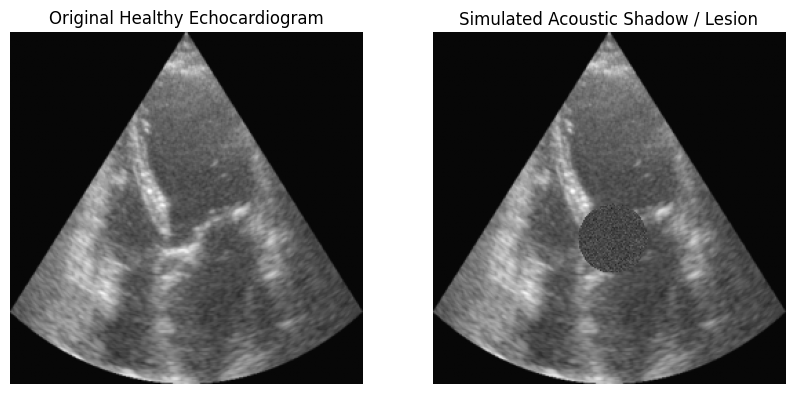

In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

def inject_acoustic_shadow(image, center=(130, 150), radius=25):
    """
    Injects a simulated acoustic shadow/dropout into the ultrasound frame.
    image shape: (256, 256, 1)
    """
    img_copy = image.copy()

    # Create coordinate grids
    Y, X = np.ogrid[:256, :256]

    # Calculate distance from the center
    dist_from_center = np.sqrt((X - center[0])**2 + (Y - center[1])**2)

    # Create a mask for the anomalous region
    mask = dist_from_center <= radius

    # Simulate a deep acoustic dropout (set pixels to near black with some noise)
    noise = np.random.normal(-0.5, 0.1, img_copy[mask].shape)
    img_copy[mask] = np.clip(noise, -1.0, 1.0)

    # THIS is the line that likely went missing!
    return img_copy

# Extract one clean batch from our PyTorch dataloader
sample_batch = next(iter(dataloader))

# Cast the PyTorch Tensor back to a NumPy array for OpenCV/Matplotlib
clean_img = sample_batch[0].numpy()

# Inject the anomaly
anomalous_img = inject_acoustic_shadow(clean_img)

# Display the comparison
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(clean_img.squeeze(), cmap='gray')
axes[0].set_title("Original Healthy Echocardiogram")
axes[0].axis('off')

axes[1].imshow(anomalous_img.squeeze(), cmap='gray')
axes[1].set_title("Simulated Acoustic Shadow / Lesion")
axes[1].axis('off')
plt.show()

In [ ]:
# 1. Define the single-patch evaluation logic
def eval_single_patch(patch_idx, img_batch, online_params, target_params):
    # Initialize blank 16x16 masks
    c_mask = jnp.ones((16, 16), dtype=bool)
    t_mask = jnp.zeros((16, 16), dtype=bool)

    # Flatten, set the specific patch index, and reshape back
    c_mask_flat = jnp.reshape(c_mask, (-1,)).at[patch_idx].set(False)
    t_mask_flat = jnp.reshape(t_mask, (-1,)).at[patch_idx].set(True)

    c_mask = jnp.reshape(c_mask_flat, (16, 16))
    t_mask = jnp.reshape(t_mask_flat, (16, 16))

    # Run the model forward pass (Returns the L2 loss for this specific patch)
    loss = model.apply({'params': online_params}, img_batch, c_mask, t_mask, target_params)
    return loss

# 2. Vectorize the function across all 256 patches
@jax.jit
def compute_anomaly_heatmap(img_batch, online_params, target_params):
    # Create an array of indices [0, 1, 2, ... 255]
    patch_indices = jnp.arange(256)

    # vmap applies the function across the patch_indices axis, but keeps the weights/images static (None)
    losses = jax.vmap(eval_single_patch, in_axes=(0, None, None, None))(
        patch_indices, img_batch, online_params, target_params
    )

    # Reshape the 256 loss values back into a 16x16 spatial grid
    return jnp.reshape(losses, (16, 16))

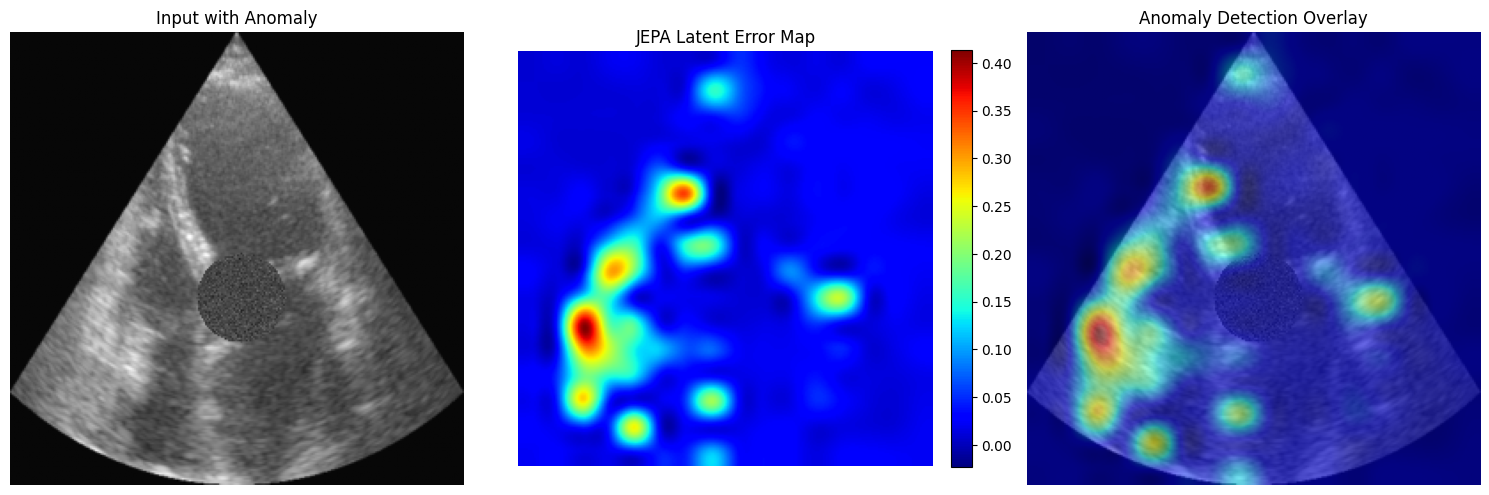

In [ ]:
# 1. Prepare the anomalous image for JAX (Shape: 1, 256, 256, 1)
jax_anomalous_img = jnp.expand_dims(jnp.array(anomalous_img), axis=0)

# 2. Compute the Latent Heatmap using our trained weights
heatmap_16x16 = compute_anomaly_heatmap(jax_anomalous_img, state.params, target_encoder_params)

# 3. Resize the 16x16 heatmap to 256x256 for visual overlay
heatmap_resized = cv2.resize(np.array(heatmap_16x16), (256, 256), interpolation=cv2.INTER_CUBIC)

# 4. Plot the results
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Plot A: The Input Image
axes[0].imshow(anomalous_img.squeeze(), cmap='gray')
axes[0].set_title("Input with Anomaly")
axes[0].axis('off')

# Plot B: The Raw Latent Error Heatmap
im = axes[1].imshow(heatmap_resized, cmap='jet')
axes[1].set_title("JEPA Latent Error Map")
axes[1].axis('off')
fig.colorbar(im, ax=axes[1], fraction=0.046, pad=0.04)

# Plot C: The Overlay
axes[2].imshow(anomalous_img.squeeze(), cmap='gray')
axes[2].imshow(heatmap_resized, cmap='jet', alpha=0.5) # Alpha blends the heatmap over the image
axes[2].set_title("Anomaly Detection Overlay")
axes[2].axis('off')

plt.tight_layout()
plt.show()